# Statistics and Machine Learning

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
telecom = pd.read_csv('telecom_cleanedwithfeatures.csv')

In [17]:
telecom.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TenureGroup,AvgMonthlySpend,NumServices,HighRiskContract,AutoPayment,FiberOpticUser,FamilyCustomer,SeniorHighCharges,LongTermCustomer,ServiceValueScore
0,7590-VHVEG,Female,0,1,0,1,0,No phone service,DSL,No,...,0-1 Year,29.850000,1,1,0,0,1,0.0,0,0.033501
1,5575-GNVDE,Male,0,0,0,34,1,No,DSL,Yes,...,2-4 Years,55.573529,2,0,0,0,0,0.0,1,0.035119
2,3668-QPYBK,Male,0,0,0,2,1,No,DSL,Yes,...,0-1 Year,54.075000,2,1,0,0,0,0.0,0,0.037140
3,7795-CFOCW,Male,0,0,0,45,0,No phone service,DSL,Yes,...,2-4 Years,40.905556,3,0,1,0,0,0.0,1,0.070922
4,9237-HQITU,Female,0,0,0,2,1,No,Fiber optic,No,...,0-1 Year,75.825000,0,1,0,1,0,0.0,0,0.000000


### Histograms to check distribution of data

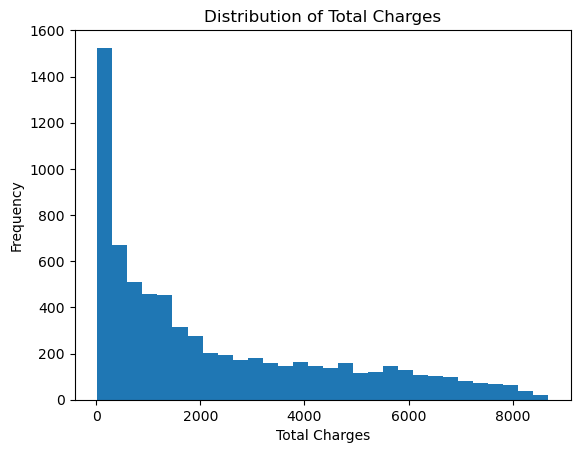

In [18]:
import matplotlib.pyplot as plt

plt.hist(telecom['TotalCharges'], bins=30)
plt.xlabel("Total Charges")
plt.ylabel("Frequency")
plt.title("Distribution of Total Charges")
plt.show()

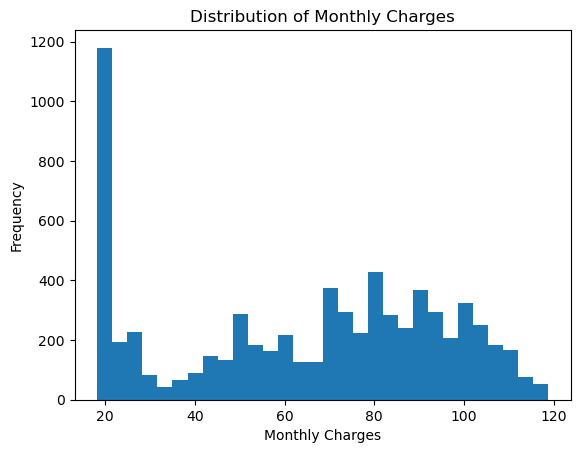

In [19]:
plt.hist(telecom['MonthlyCharges'], bins=30)
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")
plt.title("Distribution of Monthly Charges")
plt.show()

### Outlier Detection

In [20]:
Q1 = telecom['MonthlyCharges'].quantile(0.25)
Q3 = telecom['MonthlyCharges'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = telecom[
    (telecom['MonthlyCharges'] < lower) |
    (telecom['MonthlyCharges'] > upper)
]

print(outliers.shape)

(0, 31)


In [21]:
Q1 = telecom['TotalCharges'].quantile(0.25)
Q3 = telecom['TotalCharges'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = telecom[
    (telecom['TotalCharges'] < lower) |
    (telecom['TotalCharges'] > upper)
]

print(outliers.shape)

(0, 31)


### Correlation Analysis

In [22]:
numeric_df = telecom.select_dtypes(include=['int64', 'float64'])

corr = numeric_df.corr()

print(corr)

                   SeniorCitizen   Partner  Dependents    tenure  \
SeniorCitizen           1.000000  0.016957   -0.210550  0.015683   
Partner                 0.016957  1.000000    0.452269  0.381912   
Dependents             -0.210550  0.452269    1.000000  0.163386   
tenure                  0.015683  0.381912    0.163386  1.000000   
PhoneService            0.008392  0.018397   -0.001078  0.007877   
PaperlessBilling        0.156258 -0.013957   -0.110131  0.004823   
MonthlyCharges          0.219874  0.097825   -0.112343  0.246862   
TotalCharges            0.102411  0.319072    0.064653  0.825880   
Churn                   0.150541 -0.149982   -0.163128 -0.354049   
AvgMonthlySpend         0.217616  0.097130   -0.112481  0.246198   
NumServices             0.095516  0.219176    0.021635  0.527600   
HighRiskContract        0.137752 -0.280202   -0.229715 -0.649346   
AutoPayment            -0.033775  0.161327    0.094464  0.396772   
FiberOpticUser          0.254923  0.001235   -0.

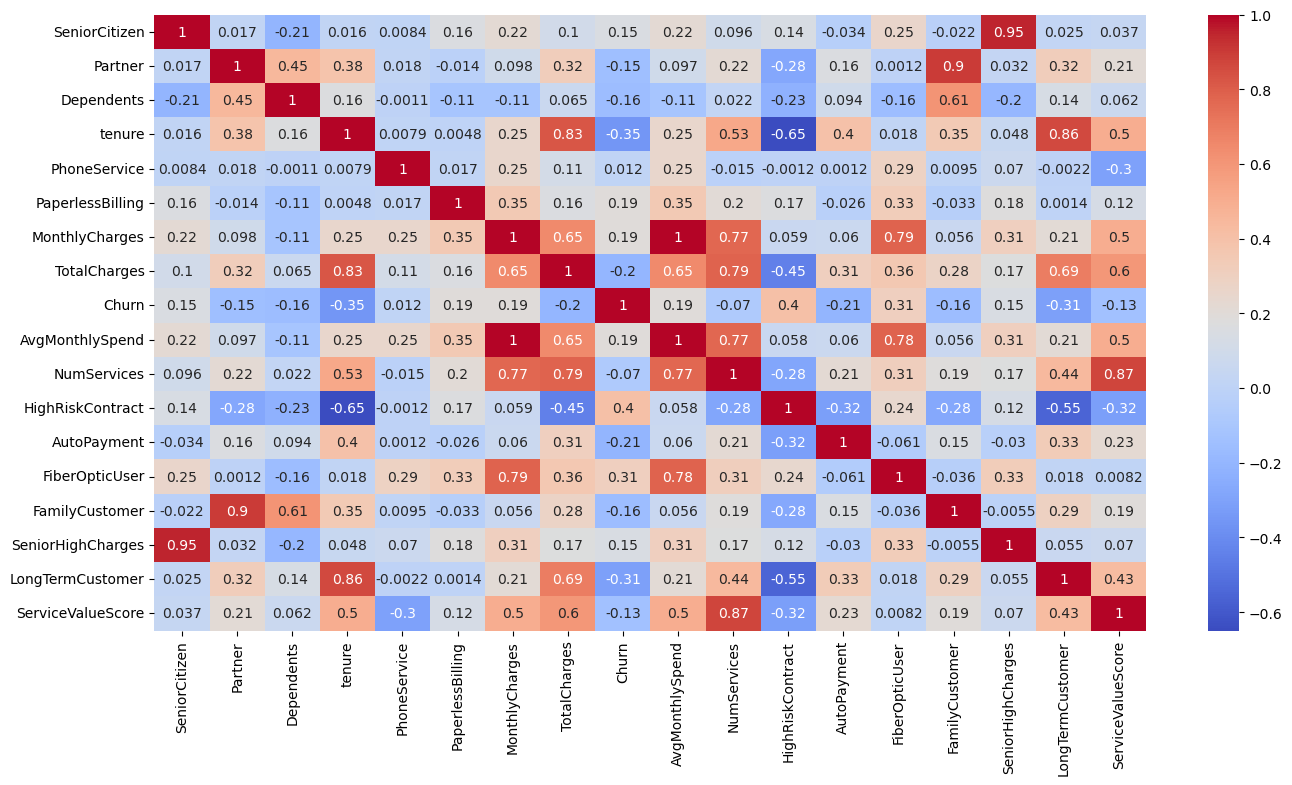

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.show()

## Hypothesis Testing

### T Test

In [24]:
from scipy.stats import ttest_ind

churn_yes = telecom[telecom['Churn'] == 1]['MonthlyCharges']
churn_no = telecom[telecom['Churn'] == 0]['MonthlyCharges']

t_stat, p_value = ttest_ind(
    churn_yes,
    churn_no
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 16.47959313114872
P-value: 6.760843117980302e-60


#### -Large positive t stat value means churned customer pay more

In [25]:
churn_yes = telecom[telecom['Churn'] == 1]['TotalCharges']
churn_no = telecom[telecom['Churn'] == 0]['TotalCharges']

t_stat, p_value = ttest_ind(
    churn_yes,
    churn_no
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -17.068827211220274
P-value: 4.876865689694505e-64


### Chi-Square Test

In [26]:
from scipy.stats import chi2_contingency

table = pd.crosstab(
    telecom['Contract'],
    telecom['Churn']
)

chi2, p, dof, expected = chi2_contingency(table)

print(chi2, p)

1179.5458287339445 7.326182186265472e-257


#### -High chi2 value and very low p value shows that there is strong relationship between two categories

# MACHINE LEARNING MODELS

In [3]:
telecom_ml = telecom.copy()

### Logistic Regression Model

In [4]:
y = telecom_ml['Churn']     # y is the Target variable and X is the Feature

In [5]:
X = telecom_ml.drop(columns=['Churn', 'customerID'])  

#### Train Test Split

In [17]:
from sklearn.model_selection import train_test_split

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test, id_train, id_test= train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

ValueError: not enough values to unpack (expected 6, got 4)

In [7]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5625, 42)
(1407, 42)
(5625,)
(1407,)


In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=5)

X_pca = pca.fit_transform(X_train_scaled)

log_model = LogisticRegression(
    max_iter=5000,
    solver='liblinear'
)

log_model.fit(X_pca, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,5000
,multi_class,'deprecated'


In [13]:
predictions = log_model.predict(pca.transform(X_test_scaled))

predictions

array([0, 1, 0, ..., 0, 0, 0], shape=(1407,))

In [25]:
predictionss = log_model.predict(X_train)

predictionss 

d:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


array([1, 1, 1, ..., 1, 1, 0], shape=(5625,))

### Evaluating Model

In [14]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.7917555081734187


In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.64      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [20]:
accuracy = accuracy_score(y_train, predictionss)

print("Accuracy:", accuracy)

Accuracy: 0.256


In [22]:
print(classification_report(y_train, predictionss))

              precision    recall  f1-score   support

           0       0.47      0.12      0.19      4130
           1       0.21      0.64      0.31      1495

    accuracy                           0.26      5625
   macro avg       0.34      0.38      0.25      5625
weighted avg       0.40      0.26      0.22      5625



### Confusion Matrix

In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

print(cm)

[[131 902]
 [149 225]]


#### This shows how many predictions are correct and uncorrect

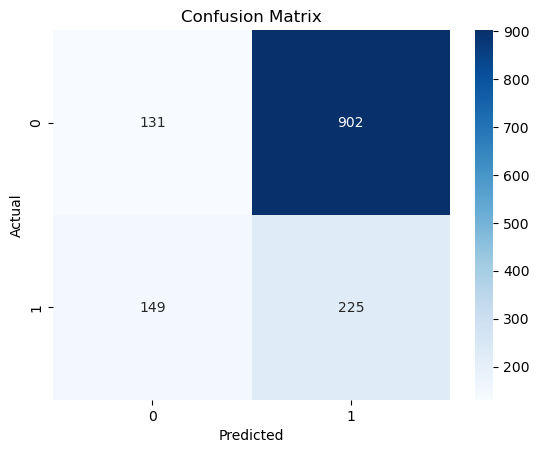

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

### Feature Importance

In [38]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0]
})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

print(importance)

                                  Feature  Coefficient
10                       HighRiskContract     0.347648
20            InternetService_Fiber optic     0.344590
12                         FiberOpticUser     0.344590
0                           SeniorCitizen     0.325778
41                  TenureGroup_4-6 Years     0.289042
31                        StreamingTV_Yes     0.275283
19                      MultipleLines_Yes     0.264182
33                    StreamingMovies_Yes     0.258393
8                         AvgMonthlySpend     0.183631
7                            TotalCharges     0.181276
9                             NumServices     0.172127
5                        PaperlessBilling     0.143815
37         PaymentMethod_Electronic check     0.105798
27                   DeviceProtection_Yes     0.103770
18         MultipleLines_No phone service     0.030192
36  PaymentMethod_Credit card (automatic)     0.026944
40                  TenureGroup_2-4 Years     0.000741
1         

## Random Forest Model

In [8]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

In [8]:
rf_model = RandomForestClassifier(
    class_weight = 'balanced',
    random_state=42
)

In [41]:
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [42]:
rf_predictions = rf_model.predict(X_test)

In [43]:
rf_predictions

array([0, 1, 0, ..., 0, 0, 0], shape=(1407,))

In [44]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7818052594171997


#### Random Forest is way more accurate than Logistic Regression

In [45]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.61      0.49      0.55       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



### Cross Validation

In [13]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=skf,
    scoring='f1'
)

print("CV Scores:", cv_scores)
print("Average CV Score:", cv_scores.mean())

CV Scores: [0.54848485 0.55098935 0.54328358 0.56541353 0.5740458 ]
Average CV Score: 0.5564434222891197


In [11]:
from sklearn.model_selection import cross_validate

scores = cross_validate(
    rf_model,
    X,
    y,
    cv=skf,
    scoring=['accuracy', 'precision', 'recall', 'f1']
)

scores

{'fit_time': array([0.80606842, 0.80126333, 0.89924669, 0.79842377, 0.74610066]),
 'score_time': array([0.03332901, 0.03097439, 0.0353353 , 0.03257895, 0.03305292]),
 'test_accuracy': array([0.78820185, 0.79033404, 0.78236131, 0.79445235, 0.80156472]),
 'test_precision': array([0.63286713, 0.63957597, 0.61279461, 0.64604811, 0.66903915]),
 'test_recall': array([0.48395722, 0.48395722, 0.48793566, 0.5026738 , 0.5026738 ]),
 'test_f1': array([0.54848485, 0.55098935, 0.54328358, 0.56541353, 0.5740458 ])}

# XG Boost Model

In [9]:
from xgboost import XGBClassifier

In [10]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    scale_pos_weight=2.7,
    random_state=42
)

In [11]:
xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [12]:
xgb_predictions = xgb_model.predict(X_test)

xgb_predictions

array([0, 1, 0, ..., 0, 0, 0], shape=(1407,))

In [13]:
y_prob = xgb_model.predict_proba(X_test)[:, 1]

In [14]:
y_prob

array([0.03885454, 0.7854305 , 0.07416947, ..., 0.09525421, 0.05899351,
       0.03470231], shape=(1407,), dtype=float32)

In [50]:
from sklearn.metrics import accuracy_score

xgb_accuracy = accuracy_score(y_test, xgb_predictions)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.7327647476901208


In [51]:
from sklearn.metrics import classification_report

print(classification_report(y_test, xgb_predictions))

              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1033
           1       0.50      0.78      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.75      1407



#### Recall matter more than accuracy. Infact it matter the most.

In [52]:
from sklearn.metrics import confusion_matrix

xgb_cm = confusion_matrix(y_test, xgb_predictions)

print(xgb_cm)

[[738 295]
 [ 81 293]]


### Feature Importance

In [53]:
xgb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by='Importance',
    ascending=False
)

print(xgb_importance)

                                  Feature  Importance
10                       HighRiskContract    0.571621
12                         FiberOpticUser    0.100826
35                      Contract_Two year    0.029294
21                     InternetService_No    0.027176
37         PaymentMethod_Electronic check    0.020876
33                    StreamingMovies_Yes    0.020720
34                      Contract_One year    0.019828
3                                  tenure    0.017658
31                        StreamingTV_Yes    0.012716
23                     OnlineSecurity_Yes    0.011021
4                            PhoneService    0.011011
6                          MonthlyCharges    0.010795
5                        PaperlessBilling    0.010531
39                  TenureGroup_1-2 Years    0.009390
7                            TotalCharges    0.008830
29                        TechSupport_Yes    0.008425
17                            gender_Male    0.008416
19                      Mult

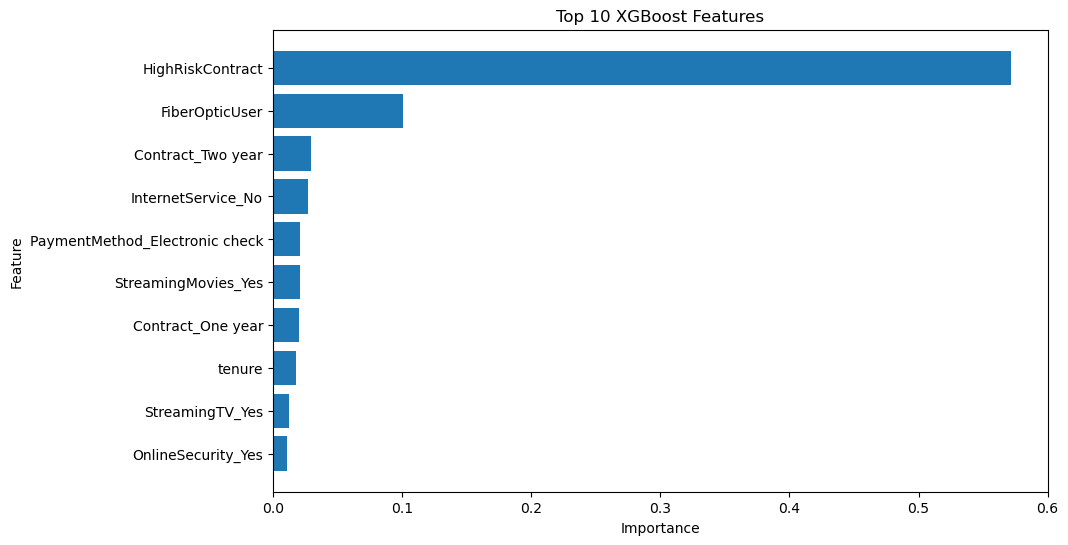

In [54]:
top_features = xgb_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 XGBoost Features")

plt.gca().invert_yaxis()

plt.show()

### ROC-AUC Score

In [55]:
from sklearn.metrics import roc_auc_score

probabilities = xgb_model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, probabilities)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.8347086260359992


0.75+ score usually strong

# SHAP Explainability

In [56]:
import shap

In [57]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    scale_pos_weight=2.7,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [58]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

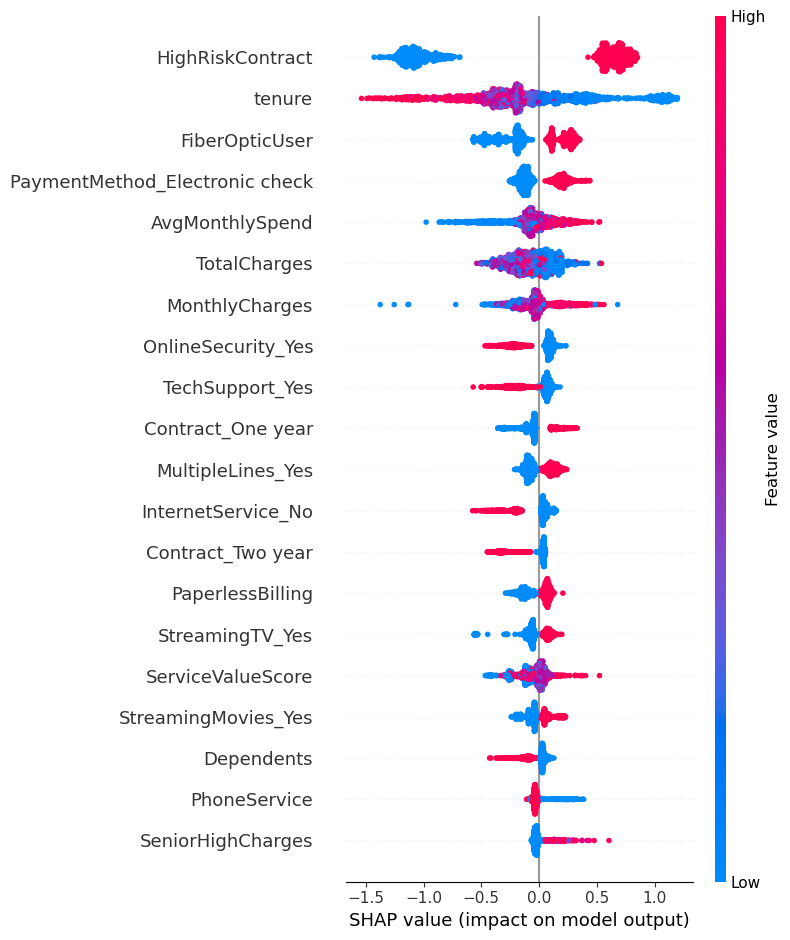

In [59]:
shap.summary_plot(shap_values, X_test)

### Cross Validation

In [16]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    scale_pos_weight=2.7,
    random_state=42
)

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    xgb_model,
    X,
    y,
    cv=skf,
    scoring='f1'
)

print("CV Scores:", cv_scores)
print("Average CV Score:", cv_scores.mean())

CV Scores: [0.61993428 0.63304721 0.62274176 0.6309922  0.60127932]
Average CV Score: 0.621598954174579


# Retention Strategy Layer

#### Risk Predictions

In [60]:
churn_prob = xgb_model.predict_proba(X_test)[:, 1]

results = X_test.copy()

results['ActualChurn'] = y_test.values
results['ChurnProbability'] = churn_prob

#### Risk Predictions

In [63]:
def risk_level(prob):
    if prob > 0.7:
        return 'High Risk'
    elif prob > 0.3:
        return 'Medium Risk'
    else:
        return 'Low Risk'

results['RiskLevel'] = results['ChurnProbability'].apply(risk_level)

In [65]:
results = results.merge(
    telecom_ml,
    left_index=True,
    right_index=True
)

#### Retention Strategy Function

In [67]:
def retention_strategy(row):

    # High-risk customers
    if row['RiskLevel'] == 'High Risk':

        # Month-to-month customers
        if row['Contract'] == 'Month-to-month':
            return 'Offer annual contract discount'

        # High monthly charges
        elif row['MonthlyCharges'] > 80:
            return 'Provide discount or bundle package'

        # New customers
        elif row['tenure'] < 6:
            return 'Provide onboarding support'

        else:
            return 'Offer loyalty rewards'

    # Medium-risk customers
    elif row['RiskLevel'] == 'Medium Risk':
        return 'Send engagement emails and service check-ins'

    # Low-risk customers
    else:
        return 'No immediate action needed'

In [70]:
results['RetentionStrategy'] = results.apply(
    retention_strategy,
    axis=1
)

In [74]:
results['RetentionStrategy'].value_counts()

RetentionStrategy
No immediate action needed                      631
Send engagement emails and service check-ins    430
Offer annual contract discount                  346
Name: count, dtype: int64

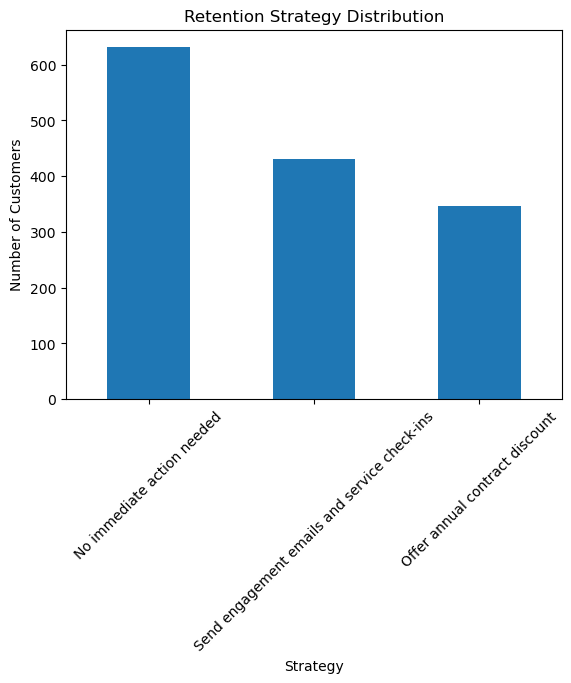

In [75]:
strategy_counts = results['RetentionStrategy'].value_counts()

strategy_counts.plot(kind='bar')

plt.title('Retention Strategy Distribution')
plt.xlabel('Strategy')
plt.ylabel('Number of Customers')

plt.xticks(rotation=45)

plt.show()

#### Revenue Impact

In [80]:
high_risk = results[results['RiskLevel'] == 'High Risk']

potential_revenue_saved = high_risk['MonthlyCharges_y'].sum()

print("Potential Monthly Revenue Saved:",
      round(potential_revenue_saved, 2))

Potential Monthly Revenue Saved: 26591.45
